In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import timm  # Import timm for Vision Transformer
import matplotlib.pyplot as plt
import numpy as np
import os
import seaborn as sns
from collections import Counter
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


C:\Users\yashp\anaconda3\envs\FER_TL\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Check GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [3]:
# Define data paths
data_dir = 'Face Expression DataSet/Data'
train_dir = os.path.join(data_dir, 'Training')
test_dir = os.path.join(data_dir, 'testing')


In [4]:
# Define data transformations (ViT expects 224x224 input)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])


In [5]:
# Load datasets
train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

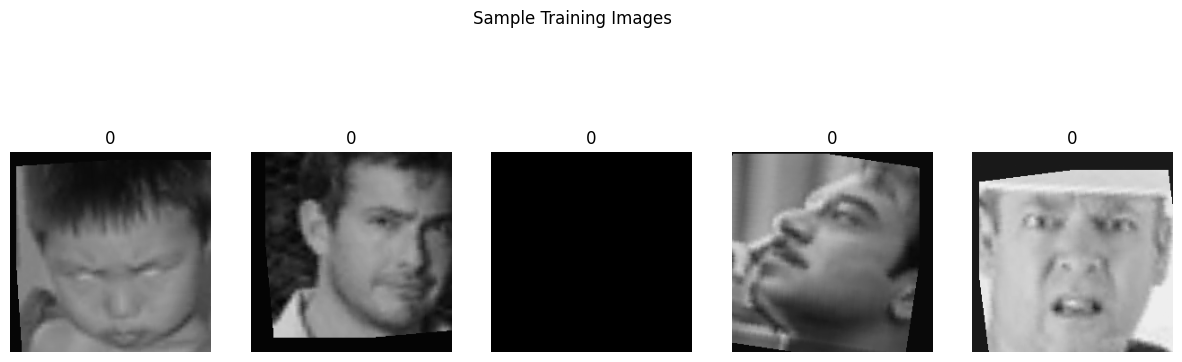

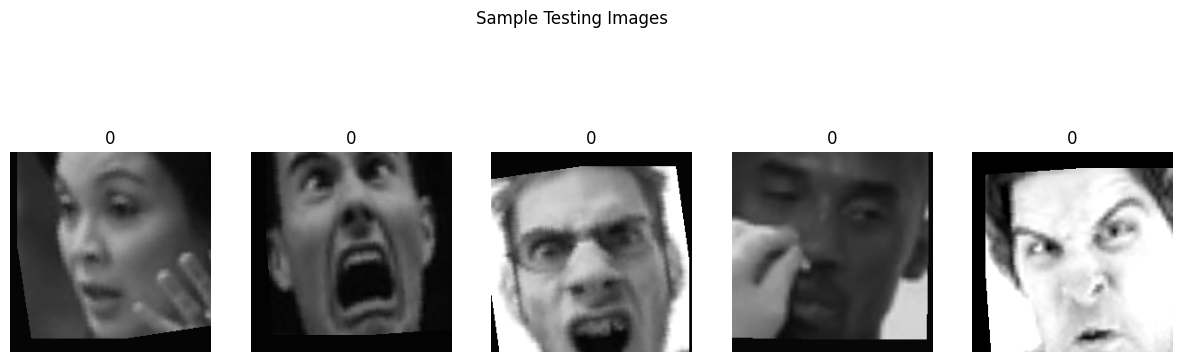

In [6]:
# Display some sample images
def show_sample_images(dataset, title, num_images=5):
    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
    for i in range(num_images):
        image, label = dataset[i]
        image = image.permute(1, 2, 0).numpy() * 0.5 + 0.5  # Unnormalize
        axes[i].imshow(image)
        axes[i].set_title(train_dataset.classes[label])
        axes[i].axis("off")
    plt.suptitle(title)
    plt.show()

show_sample_images(train_dataset, "Sample Training Images")
show_sample_images(test_dataset, "Sample Testing Images")

In [7]:
# Load Vision Transformer Model
#model = timm.create_model("vit_base_patch16_224", pretrained=True, num_classes=len(train_dataset.classes))
model = timm.create_model("vit_base_patch16_224", pretrained=True, num_classes=len(train_dataset.classes), drop_rate=0.3)
model = model.to(device)
print(model)

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)
        (norm): Identity(

In [8]:
# Split dataset into training and validation
from torch.utils.data import DataLoader, random_split
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])
train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [9]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.00005)  # Half of original lr
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

In [12]:
# Early Stopping Class
class EarlyStopping:
    def __init__(self, patience=5, path='best_model_VIT.pth'):
        self.patience = patience
        self.best_loss = float('inf')
        self.counter = 0
        self.early_stop = False
        self.path = path

    def __call__(self, val_loss, model=None):  # Make model optional
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
            if model:
                torch.save(model.state_dict(), self.path)  # Save best model
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True



# Training Loop
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=10):
    model.train()
    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
    early_stopping = EarlyStopping(patience=5)
    
    for epoch in range(epochs):
        running_loss = 0.0
        all_preds, all_labels = [], []
        for images, labels in tqdm(train_loader):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            all_preds.extend(torch.argmax(outputs, 1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
        
        acc = accuracy_score(all_labels, all_preds)
        history['loss'].append(running_loss / len(train_loader))
        history['accuracy'].append(acc)
        
        # Validation
        model.eval()
        val_loss, val_preds, val_labels = 0.0, [], []
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                val_preds.extend(torch.argmax(outputs, 1).cpu().numpy())
                val_labels.extend(labels.cpu().numpy())
        
        val_acc = accuracy_score(val_labels, val_preds)
        history['val_loss'].append(val_loss / len(val_loader))
        history['val_accuracy'].append(val_acc)
        print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}, Accuracy: {acc:.4f}, Val Loss: {val_loss/len(val_loader):.4f}, Val Accuracy: {val_acc:.4f}")
        
        scheduler.step()
        early_stopping(val_loss)
        if early_stopping.early_stop:
            print("Early stopping triggered.")
            break
    
    return history

In [13]:
# Train the model
history = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=30)

100%|██████████| 320/320 [03:28<00:00,  1.53it/s]


Epoch 1, Loss: 1.0614, Accuracy: 0.5970, Val Loss: 1.1060, Val Accuracy: 0.5832


100%|██████████| 320/320 [03:32<00:00,  1.51it/s]


Epoch 2, Loss: 0.8903, Accuracy: 0.6658, Val Loss: 1.0278, Val Accuracy: 0.6180


100%|██████████| 320/320 [03:33<00:00,  1.50it/s]


...

Epoch 6, Loss: 0.2149, Accuracy: 0.9261, Val Loss: 1.4847, Val Accuracy: 0.6379


100%|██████████| 320/320 [03:34<00:00,  1.50it/s]


Epoch 7, Loss: 0.1429, Accuracy: 0.9526, Val Loss: 1.6231, Val Accuracy: 0.6438


100%|██████████| 320/320 [03:33<00:00,  1.50it/s]


Epoch 8, Loss: 0.1091, Accuracy: 0.9625, Val Loss: 1.7018, Val Accuracy: 0.6375
Early stopping triggered.


In [14]:
# Save Model
torch.save({'model_state_dict': model.state_dict(), 'optimizer_state_dict': optimizer.state_dict()}, "vit_emotion_recognition.pth")
print("Model saved successfully.")

Model saved successfully.


100%|██████████| 32/32 [00:09<00:00,  3.43it/s]


Accuracy: 0.6720
Precision: 0.6835
Recall: 0.6720
F1-score: 0.6739


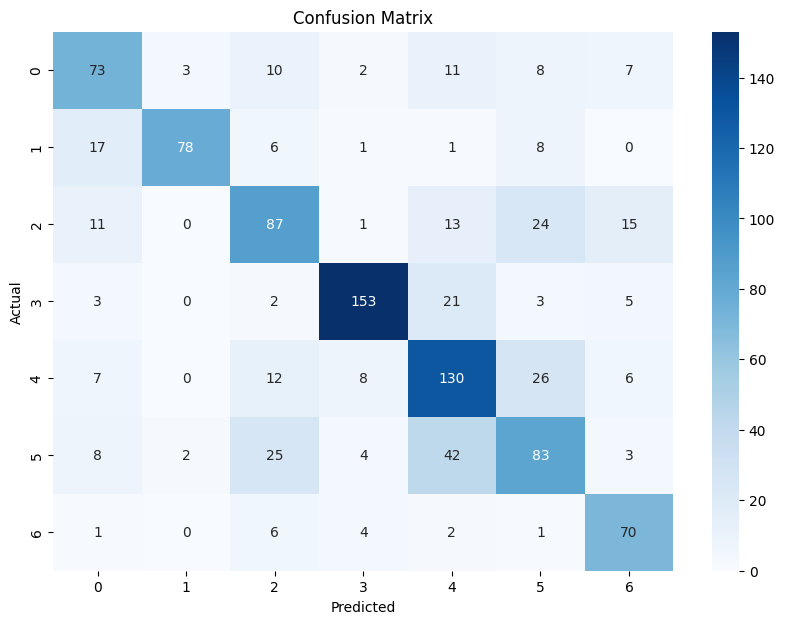

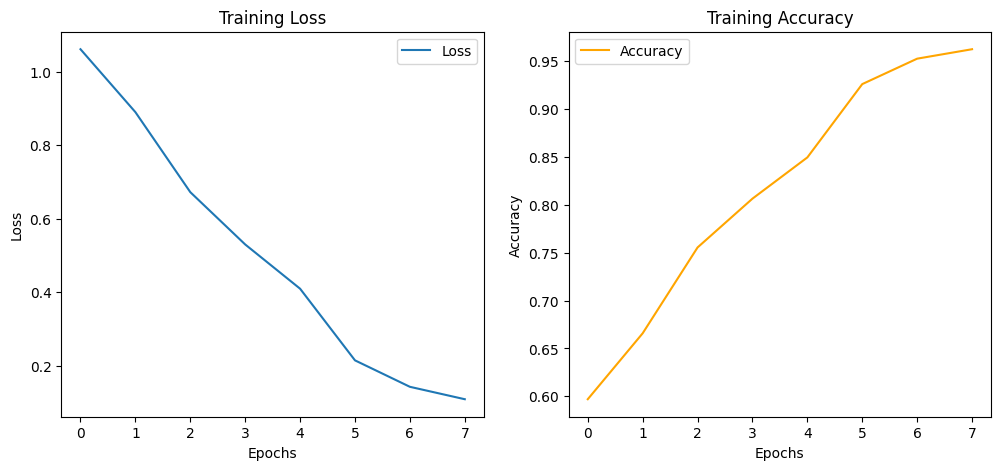

In [15]:
# Evaluation on test set
def evaluate_model(model, test_loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in tqdm(test_loader):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            all_preds.extend(torch.argmax(outputs, 1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')
    cm = confusion_matrix(all_labels, all_preds)
    
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=train_dataset.classes, yticklabels=train_dataset.classes)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

# Evaluate the model
evaluate_model(model, test_loader)

# Plot Accuracy & Loss Graph
def plot_metrics(history):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['loss'], label='Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history['accuracy'], label='Accuracy', color='orange')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training Accuracy')
    plt.legend()
    
    plt.show()

# Plot the metrics
plot_metrics(history)

In [ ]:
# Evaluation on test set
def evaluate_model(model, test_loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in tqdm(test_loader):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            all_preds.extend(torch.argmax(outputs, 1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')
    cm = confusion_matrix(all_labels, all_preds, normalize='true')
    
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', xticklabels=train_dataset.classes, yticklabels=train_dataset.classes)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

# Evaluate the model
evaluate_model(model, test_loader)
